In [ ]:
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
def gen_impulses(fs, dur, isi, height=1, jitter=0):
    n = int(dur*fs)
    isis = np.atleast_1d(isi)
    X = np.zeros((n, len(isis)))
    for i, isi in enumerate(isis):
        t_event = np.arange(isi, dur, isi)
        t_event += np.random.uniform(-jitter, jitter, t_event.size)
        idx = (t_event * fs).astype(int)
        h = height if not isinstance(height, list) else height[i]
        X[idx, i] = h
    t = np.linspace(0, dur, n)
    return X, t

def gen_trf(fs, dur, peak, width):
    peaks = np.atleast_1d(peak)
    trf = np.zeros((int(fs*dur), len(peaks)))
    t = np.linspace(0, dur, int(dur*fs))
    for i, peak in enumerate(peaks):
        w = width if not isinstance(width, list) else width[i]
        trf[:,i] = np.exp(-((t - peak) ** 2) / (2 * w** 2))
    return trf, t

def simulate_response(X, trf, noise_factor=1):
    y = np.zeros(len(X))
    for i in range(X.shape[1]):
        y += np.convolve(X[:, i], trf[:, i], mode="full")[:len(X)]
    y -= y.mean()
    y /= X.shape[1]
    y += np.random.randn(y.size)*noise_factor
    return y

def gen_lags(X, n_lags):
    n, k = X.shape
    X_lag = np.zeros((n, k * n_lags))
    for lag in range(n_lags):
        X_lag[lag:, lag*k:(lag+1)*k] = X[:n-lag]
    return X_lag


class utils:
    gen_trf = gen_trf
    gen_impulses = gen_impulses
    gen_lags = gen_lags
    simulate_response = simulate_response
    mse = mse
    pearsonr = pearsonr
    r_squared = r_squared

## Creating a Time-Lagged Design Matrix

| Code | Description |
| --- | --- |
| `utils.gen_impulses(fs, dur=2, isi=0.5)` | Generate a `1.5` second sequence of impulses with sampling rate `fs` and `0.2` second intervals between impulses | 
| `plt.imshow(X, aspect="auto")` | Plot `X` as an image with automatical scaling of the axes |
| `np.zeros((10, 3))` | Create a 10-by-3 array where all values are zero |

Generate impulse stimulus at `100` Hz sampling rate.

In [ ]:
fs = 100
X, t = utils.gen_impulses(fs, dur=1.5, isi=0.2)
plt.plot(X);

**Example**: Generate and plot design matrix with 5 lags.

In [ ]:
n_lag = 5
n, _ = X.shape
X_lag = np.zeros((n, n_lag))
for lag in range(n_lag):
    X_lag[lag:, lag:(lag+1)] = X[:n-lag]

plt.imshow(X_lag, aspect="auto")

**Excercise**: Generate and plot design matrix with 20 lags.

In [ ]:
n_lag = 20
n, _ = X.shape
X_lag = np.zeros((n, n_lag))
for lag in range(n_lag):
    X_lag[lag:, lag:(lag+1)] = X[:n-lag]

plt.imshow(X_lag, aspect="auto", interpolation=None)
plt.ylabel("Samples")
plt.xlabel("Lags")

Generate two stimulus features of opposite sign and differnt ISI

In [ ]:
X, t = utils.gen_impulses(fs=100, dur=1.5, isi=[0.2, 0.3], height=[1, -1])
plt.plot(t, X);

**Exercise**: Create a design matrix with 10 lags.

In [ ]:
n_lag = 10
n, k = X.shape
X_lag = np.zeros((n, k * n_lag))
for lag in range(n_lag):
    X_lag[lag:, lag*k:(lag+1)*k] = X[:n-lag]

plt.imshow(X_lag, aspect="auto", interpolation=None)

**Exercise**: generate the same design matrix with the `utils.gen_lags()` function.

In [ ]:
X_lag = utils.gen_lags(X, n_lags=10)
plt.imshow(X_lag, aspect="auto", interpolation=None)

## Time-Lagged Regression

| Description | Code | 
| --- | --- |
| `X, t = utils.gen_impulses(fs, dur=60, isi=0.2)` | Generate a `60` second sequence of impulses with sampling rate `fs` and `0.2` second intervals between impulses |
| `trf, t_trf = utils.gen_trf(fs, dur=0.3, peak=0.1, width=0.03)` | Genrate a TRF with a duration of `0.3` seconds and width of `0.03` seconds which peaks at `0.1` seconds |
| `y = utils.simulate_response(X, trf)`| Simulate a neural response by convolving `X` with the `trf` and adding noise |
| `X_lag = utils.gen_lags(X, n_lags=20)` | Return a matrix with `20` time lags of `X` |
| `b.reshape(20, 4)` | Reshape `b` to a 20-by-4 array (only works if `b` has exactly 80 elements)` |

Simulate neural response from impulses and TRF

In [ ]:
fs = 100

X, t = utils.gen_impulses(fs, dur=60, isi=0.2)
trf, t_trf = utils.gen_trf(fs, dur=0.3, peak=0.1, width=0.03)
y = utils.simulate_response(X, trf)

fig, ax = plt.subplots(3)
ax[0].plot(t[:1000], X[:1000])
ax[1].plot(t_trf, trf)
ax[2].plot(t[:1000], y[:1000])
plt.tight_layout()

In [ ]:
X_lag = utils.gen_lags(X, n_lags=20)
plt.imshow(X_lag[:100], aspect="auto")

In [ ]:
b = np.linalg.solve(X_lag.T @ X_lag, X_lag.T@y)
plt.plot(b)

In [ ]:
X_lag = utils.gen_lags(X, n_lags=20)
X_lag = np.c_[np.ones((len(X_lag), 1)), X_lag]
b = np.linalg.solve(X_lag.T @ X_lag, X_lag.T@y)
plt.plot(b[1:])

In [ ]:
fs = 150

X, t = utils.gen_impulses(fs, dur=120, isi=[0.2, 0.5])
trf, t_trf = utils.gen_trf(fs, dur=0.3, peak=[0.06, 0.11], width=[0.02, 0.03])
y = simulate_response(X, trf, noise_factor=0.1)

fig, ax = plt.subplots(3)
ax[0].plot(X[:1000, :])
ax[1].plot(trf)
ax[2].plot(y)

In [ ]:
max_lag = 30
n, k = X.shape
X_lag = np.zeros((n, k * max_lag))
for lag in range(max_lag):
    X_lag[lag:, lag*k:(lag+1)*k] = X[:n-lag]

X_lag = np.c_[np.ones((n, 1)), X_lag]
b = np.linalg.solve(X_lag.T @ X_lag, X_lag.T@y)

b.shape

In [ ]:
plt.plot(b[1:].reshape(max_lag, k)
);

## Evaluating Model Accuracy

| Code | Description |
| --- | --- |
| `np.convolve(X, b)` | Convolve `X` with the kernel `b` |
| `np.mean((y - y_pred) ** 2)` | Calculate the mean squared error (MSE) |
| `np.corrcoef(y, y_pred)` | Calculate Pearson's correlation coefficient $r$ |
| `ss_res = np.sum((y - y_pred) ** 2)` | Calculate the sum of squared residuals |
| `ss_tot = np.sum((y - y.mean()) ** 2)` | Calculate the total sum of squares |
| `1 - ss_res / ss_tot` | Calculate the coefficient of determination $R^2$ |



def pearsonr(y_true, y_pred):
    return np.corrcoef(y_true, y_pred)[0, 1]

def r_squared(y_true, y_pred):
    return 1 - ss_res / ss_tot

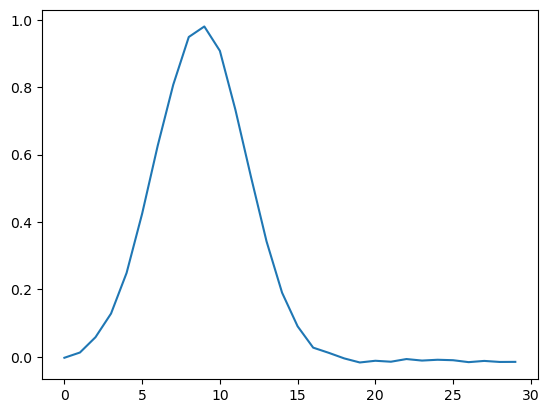

In [28]:
fs = 150

X, t = utils.gen_impulses(fs, dur=120, isi=0.2)
trf, t_trf = utils.gen_trf(fs, dur=0.3, peak=0.06, width=0.02)
y = simulate_response(X, trf, noise_factor=0.1)

max_lag = 30
n, k = X.shape
X_lag = np.zeros((n, k * max_lag))
for lag in range(max_lag):
    X_lag[lag:, lag*k:(lag+1)*k] = X[:n-lag]

X_lag = np.c_[np.ones((len(X_lag), 1)), X_lag]
b = np.linalg.solve(X_lag.T @ X_lag, X_lag.T@y)
b.shape

trf_reconstructed = b[1:].reshape(max_lag, k)

plt.plot(trf_reconstructed);

In [30]:
X.shape

(18000, 1)

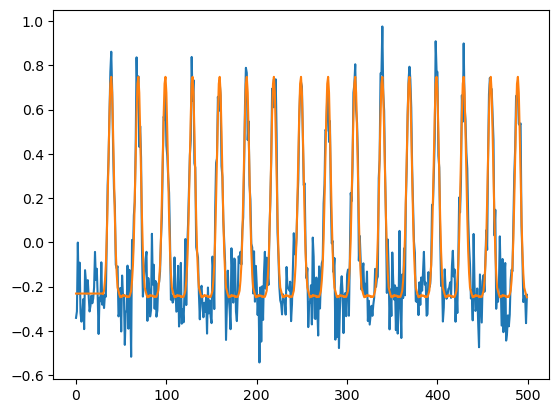

In [38]:
y_pred = np.convolve(X.flatten(), b[1:], mode="full")[:n] + b[0]
plt.plot(y[:500])
plt.plot(y_pred[:500])

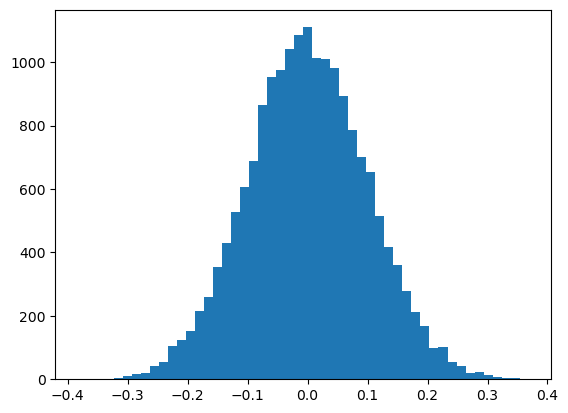

In [40]:
plt.hist(y-y_pred, bins=50);

In [43]:
np.corrcoef(y, y_pred)[0, 1]

np.float64(0.9586929203299022)